In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pycatch22
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_distances

from imblearn.over_sampling import SMOTE

In [18]:
def to_csv(ProbsIndex,ProbValues,adress):

    ProbValues = pd.concat([ProbValues,ProbsIndex[["label","original"]]],axis=1)
    print(ProbValues.head())




def readFormatProbabilitys(adress:str):
    data = pd.read_csv(adress,header=None)
    
    values = []
    for i,j in data.groupby(1):
        values.append([j[0].values[0],j[1].values[0],j[2].values])

    df = pd.DataFrame(values)
    df = df.rename(columns={0:"leftNode",
                       1:"rightNode",
                       2:"probability"})
    return df

def readFormatExcludedlinks(adress:str):

    
    dfExcluded = pd.read_csv(adress,header=None)
    dfExcluded = dfExcluded.rename(columns= {0:"leftNode",
                                     1:"rightNode"})
    
    return dfExcluded

In [129]:
def evaluation():
    dfProbsIndex = readFormatProbabilitys("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/rating/OurMethod/82695.csv")
    dfExcluded = readFormatExcludedlinks("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/rating.testGraph.csv")
    OriginalEdges = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/ratingtrainGraph.csv",header = None)
   

    OriginalEdges = OriginalEdges.rename(columns={1:"rightNode",
                       0:"leftNode"})
    

    # print(len(OriginalEdges[OriginalEdges.leftNode == 47019]))
    # print(len(dfExcluded[dfExcluded.leftNode == 47019].rightNode.values[0]))

    dfProbsValues = pd.DataFrame([i for i in dfProbsIndex.probability.values])

    

    dfProbsIndex["label"] = dfProbsIndex.rightNode.isin(dfExcluded[dfExcluded["leftNode"] == 82695].rightNode.values).astype(int)
    
    dfProbsIndex["original"] = dfProbsIndex["rightNode"].isin(OriginalEdges[OriginalEdges["leftNode"] == 82695].rightNode.values).astype(int)

    print(dfProbsIndex["original"].value_counts())
    # excluded_nodes = set()
    # rows = dfExcluded[dfExcluded["leftNode"] == 82695]
    # if not rows.empty:
    # excluded_nodes = set(rows["rightNode"].values)

    for col in dfProbsValues.columns:
        media = dfProbsValues[col].mean()
        dfProbsValues.loc[dfProbsValues[col].isin([0, 1]), col] = media

 

    dfProbsIndex_bal, dfProbsValues_bal = dfProbsIndex, dfProbsValues

    return dfProbsIndex_bal, dfProbsValues_bal


In [ ]:
def plotColumns(ProbsIndex,ProbValues):

    scaled_df = pd.concat([pd.DataFrame(ProbValues),ProbsIndex["label"],ProbsIndex["original"]],axis=1)

    green = scaled_df[scaled_df["label"] == 1].copy().drop(columns=["original","label"])
    blue = scaled_df[scaled_df["label"] == 0].copy().drop(columns=["original","label"])
    red = scaled_df[(scaled_df["original"] == 1)].copy().drop(columns=["original","label"])

    red["mean"] = red.mean(axis=1)
    red["std"] = red.std(axis=1)

    # blue = blue.sample(4000)
    blue["mean"] = blue.mean(axis=1)
    blue["std"] = blue.std(axis=1)

    green["mean"] = green.mean(axis=1)
    green["std"] = green.std(axis=1)

    plt.scatter(green["mean"],green["std"],c="green")
    plt.scatter(red["mean"],red["std"],c="red")
    plt.scatter(blue["mean"],blue["std"],c="blue")


    # for column in red.columns:
    #     plt.scatter(red[column].mean(),red[column].std(),c="red")
    #     plt.scatter(blue[column].mean(),blue[column].std(),c="blue")
    #     plt.scatter(green[column].mean(),green[column].std(),c="green")
    


    plt.xlabel("mean")
    plt.ylabel("var")
    plt.plot()
    plt.show()

In [135]:
import umap
def plotScatter(ProbsIndex,ProbValues,Pca):

    # ProbsIndex["L3"] = ProbsIndex.rightNode.isin(aux[aux["right_nodes"] == 1454].head(100).left_nodes.values).astype(int)

    fig = plt.figure(figsize=(25,25))
    ax = fig.add_subplot()
    
    # ProbValues = pd.DataFrame(ProbValues.rolling(window=5,min_periods=1).mean().values)
    # ProbValues = ProbValues.T
    # y=pd.DataFrame([pycatch22.catch22_all((ProbValues.iloc[:,i].values)) for i in range(ProbValues.shape[1])])
    # ProbValues = pd.DataFrame((np.array([i for i in y["values"].fillna(0).values])))


    if(Pca == True):
        # scaler = StandardScaler()
        # X_scaled = scaler.fit_transform(ProbValues)
        pca = PCA(n_components=2)
        values = pca.fit_transform(ProbValues)
    else:
        # reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
        # values = reducer.fit_transform(ProbValues)

        tsne = TSNE(n_components=2, random_state=0, perplexity=15)
        values = tsne.fit_transform(np.array(ProbValues))
        
    scaled_df = pd.concat([pd.DataFrame(values),ProbsIndex["label"],ProbsIndex["original"]],axis=1)

    green = scaled_df[scaled_df["label"] == 1]
    blue = scaled_df[scaled_df["label"] == 0]
    # blue = blue.sample(400)

    red = scaled_df[(scaled_df["original"] == 1)]
    # green = scaled_df[scaled_df["L3"] == 1]


   


    
    ax.scatter(blue[[0]], blue[[1]],c="blue")
    ax.scatter(red[[0]], red[[1]],c="red")
    ax.scatter(green[[0]], green[[1]],c="green")
    # ax.scatter(black[[0]],black[[1]],c="green",marker= "X",s=100)

    # ax.set_ylim(-5,15)
    # ax.set_xlim(15,35)


    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    plt.xlabel('Principal Component 1', fontsize=20)
    plt.ylabel('Principal Component 2', fontsize=20)



    plt.show()


In [24]:
import subprocess

nn = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv",header=None)
# nn.drop(nn[nn[1] == 2051].head(50).index,inplace=True)
current_path = "/home/edu/Area_de_Trabalho/Projs/links/"
def calculate_metric(train_graph):

        train_graph["weight"] = 1
        train_graph.to_csv(f"{current_path}/data/kpisti-L3-a163e9f/graph.txt",header=None,sep=" ",index=False)
        subprocess.run(f"/home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/teste.out /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/graph.txt", shell=True)
        subprocess.run(f"mv /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt.dat /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", shell=True)
        result = pd.read_csv(f"{current_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt",sep="\t",header=None)
        result.columns = ["left_nodes","right_nodes","pred"]
        return result

aux = calculate_metric(nn)

In [142]:
aux[aux["right_nodes"] == 930].head(100).left_nodes.values

array([138849, 138789, 138811, 138973, 138753, 138603, 139082, 139703,
       139689, 139763, 138543, 139273, 138525, 138540, 138643, 139101,
       139351, 140073, 141452, 139733, 138873, 139090, 138860, 139141,
       139758, 139529, 139088, 140214, 142799, 139083, 138837, 139784,
       142071, 141121, 139590, 139707, 138658, 139582, 141209, 139034,
       139690, 140020, 139699, 145646, 140197, 138503, 139032, 145032,
       138724, 138809, 139693, 139229, 139686, 139079, 138786, 139739,
       143842, 139714, 138716, 139271, 140277, 139080, 138850, 140103,
       141411, 145367, 138842, 140784, 140066, 139886, 141199, 140410,
       139417, 143379, 138604, 139706, 141640, 138514, 142504, 140461,
       138746, 140225, 139594, 138495, 138701, 140077, 140505, 138785,
       144870, 140667, 141409, 139243, 140504, 139751, 139573, 139900,
       138947, 139715, 145931, 138781])

In [130]:
a,b = evaluation()

original
0    7314
1     176
Name: count, dtype: int64


label
0    7471
1      19
Name: count, dtype: int64


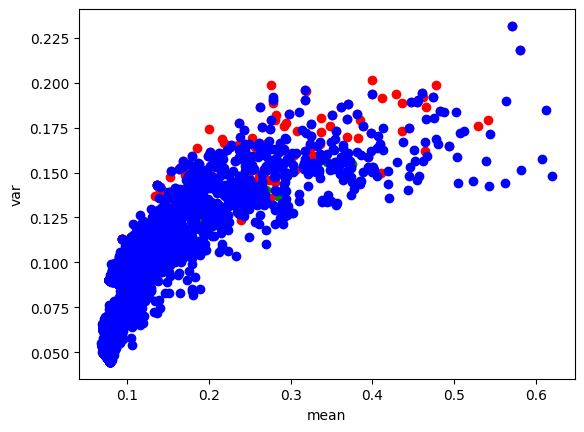

In [157]:
plotColumns(a,b)